Accuracy: 0.93


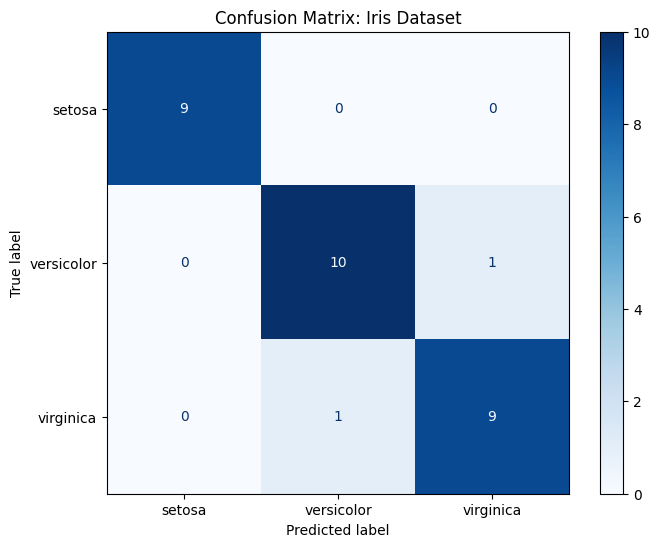

In [26]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Dataset setup
data = load_iris()
X = data.data
y = data.target

# 2. Split (using your random_state 41)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# 3. Model initialization and training
# max_iter increased to ensure convergence on this dataset
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 4. Predictions
predictions = model.predict(X_test)

# 5. Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')

# 6. CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Iris Dataset')
plt.show()

0.5558915986952425


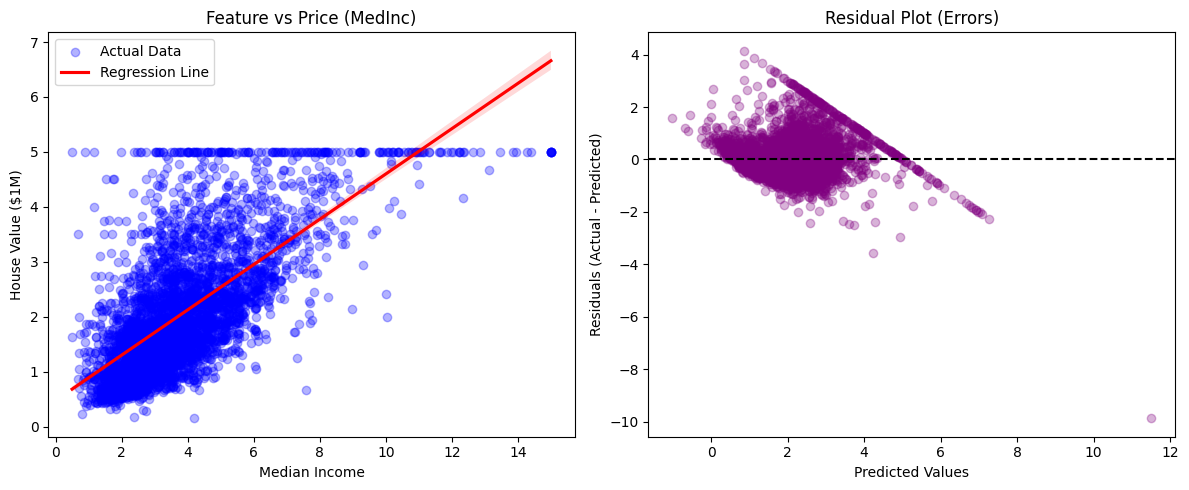

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Load Data
housing = fetch_california_housing()


## Applicare rimozione outlier con z score = 3


X = housing.data
y = housing.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Predictions and Residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)

print(mse)

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($1M)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

Rows removed: 482
Mean Squared Error: 0.4534


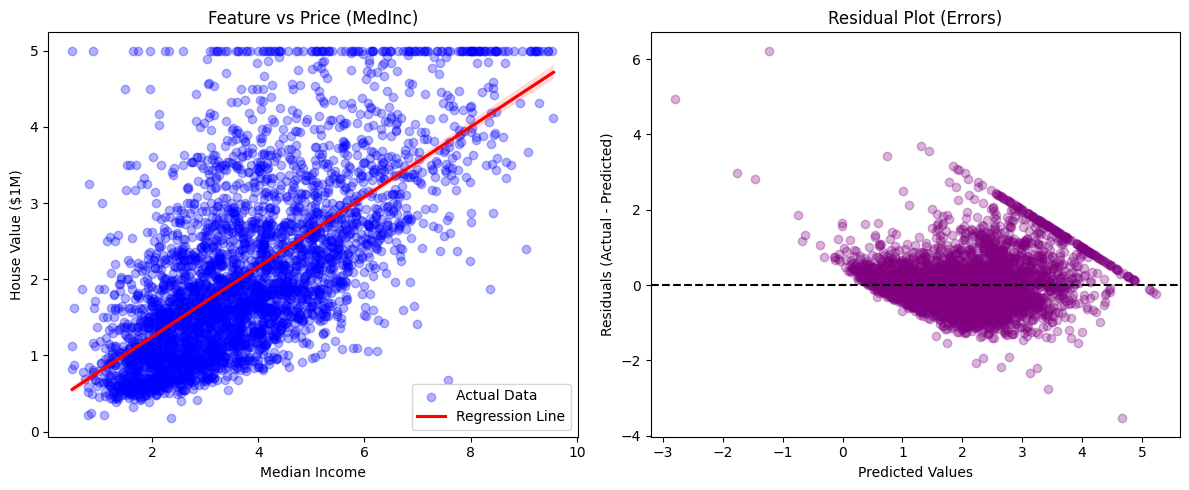

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from scipy import stats
import pandas as pd

# 1. Load Data
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target to the dataframe so it stays synchronized during filtering
df_housing['MedHouseVal'] = housing.target

## Outlier removal function (stays the same)
def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    z_scores = np.abs(stats.zscore(df_clean[columns]))
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# 2. Apply filtering
df_zscore = remove_outliers_zscore(df_housing, ['MedInc', 'AveRooms', 'AveOccup'])
print(f"Rows removed: {len(df_housing) - len(df_zscore)}")

# 3. Redefine X and y from the cleaned DataFrame
# X is everything except the target; y is just the target
X = df_zscore.drop(columns=['MedHouseVal']).values 
y = df_zscore['MedHouseVal'].values

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predictions
y_pred = model.predict(X_test)
residuals = y_test - y_pred

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

# 4. PLOTTING
plt.figure(figsize=(12, 5))

# --- Plot 1: Regression Line (using 'Median Income' which is index 0) ---
plt.subplot(1, 2, 1)
# Plotting only the first feature (Median Income) vs Target
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Actual Data')
# Fit a simple line just for this plot to visualize the trend
sns.regplot(x=X_test[:, 0], y=y_test, scatter=False, color='red', label='Regression Line')
plt.title('Feature vs Price (MedInc)')
plt.xlabel('Median Income')
plt.ylabel('House Value ($1M)')
plt.legend()

# --- Plot 2: Residual Plot ---
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='purple', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='--') # Zero error line
plt.title('Residual Plot (Errors)')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')

plt.tight_layout()
plt.show()

In [29]:
import seaborn as sns

# Load the built-in titanic dataset
df = sns.load_dataset('titanic')

# Display the first 5 rows
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


# Da fare

- ripulire il dataset
- convertire categorie in numeri
- rimuovere outlier con z-score 3
- feature engineering
- normalizzare
- applicare logistic regression

## Pulizia dei dati
1. Rimozione di dati di colonna class
2. Rimozione dei NaN

In [30]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [31]:
# Rimozione dati di colonna class
df = df.drop(columns=['class', 'who', 'embarked', 'alive'])

# Rimozione dei NaN dalla colonna deck
# df = df.dropna(subset=['deck'])

# Sostituzione dei NaN con la modalità più frequente (per la colonna deck)
most_frequent_deck = df['deck'].mode()[0]
df['deck'] = df['deck'].fillna(most_frequent_deck)
df['age'] = df['age'].fillna(df['age'].median())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])

df.info()
df.describe()

print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   adult_male   891 non-null    bool    
 8   deck         891 non-null    category
 9   embark_town  891 non-null    str     
 10  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(2)
memory usage: 58.8 KB
   survived  pclass     sex   age  sibsp  parch     fare  adult_male deck  \
0         0       3    male  22.0      1      0   7.2500        True    C   
1         1       1  female  38.0      1      0  71.2833       False    C   
2         1       3  female  26.0  

## `Convertir  categorie in numeri`

In [32]:
# Conversione delle categorie in numeri
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embark_town'] = df['embark_town'].map({'Southampton': 0, 'Cherbourg': 1, 'Queenstown': 2})
df['deck'] = df['deck'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'T': 7})
print(df.head())

   survived  pclass  sex   age  sibsp  parch     fare  adult_male deck  \
0         0       3    0  22.0      1      0   7.2500        True    2   
1         1       1    1  38.0      1      0  71.2833       False    2   
2         1       3    1  26.0      0      0   7.9250       False    2   
3         1       1    1  35.0      1      0  53.1000       False    2   
4         0       3    0  35.0      0      0   8.0500        True    2   

   embark_town  alone  
0            0  False  
1            1  False  
2            0   True  
3            0  False  
4            0   True  


## `Rimozione outlier con z-score 3`

In [33]:
# Rimozione outlier con z score = 3
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
print(f"Dimensioni originali del dataset: {df.shape}")
df_zscore = remove_outliers_zscore(df, ['age', 'fare', 'parch', 'sibsp'])
print(f"Dimensioni dopo rimozione outlier: {df_zscore.shape}")
print(f"Righe rimosse con Z-Score: {len(df) - len(df_zscore)}")

Dimensioni originali del dataset: (891, 11)
Dimensioni dopo rimozione outlier: (820, 11)
Righe rimosse con Z-Score: 71


## `Feature Engineering`

family_size
0    524
1    155
2    100
3     28
4      9
5      4
Name: count, dtype: int64


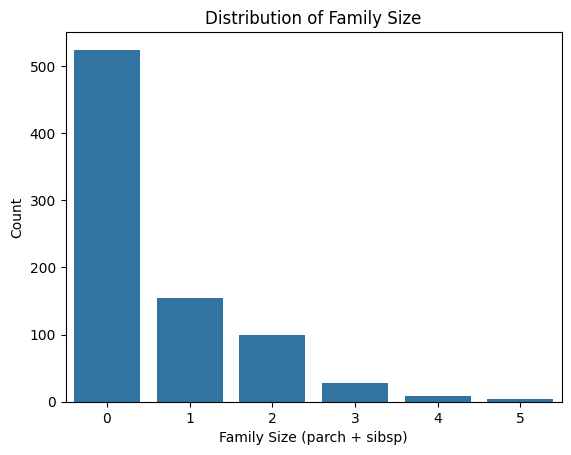

In [34]:
# Feature Engineering: creazione di una nuova colonna "family_size" su df originale
# Poi si può fare anche su df_zscore se vogliamo, ma per ora lo facciamo su df originale
#arrotondamento di famly_size

df_zscore['family_size'] = df_zscore['parch'] + df_zscore['sibsp']
df_zscore['family_size'] = df_zscore['family_size'].round(2)
print(df_zscore['family_size'].value_counts())


sns.countplot(x='family_size', data=df_zscore)
plt.title('Distribution of Family Size')
plt.xlabel('Family Size (parch + sibsp)')
plt.ylabel('Count')
plt.show()

## `Normalizzazione`

              age        fare       parch       sibsp
count  820.000000  820.000000  820.000000  820.000000
mean     0.442585    0.156709    0.127439    0.116260
std      0.185628    0.180858    0.282654    0.206478
min      0.000000    0.000000    0.000000    0.000000
25%      0.344312    0.047892    0.000000    0.000000
50%      0.420555    0.078852    0.000000    0.000000
75%      0.527295    0.163769    0.000000    0.333333
max      1.000000    1.000000    1.000000    1.000000


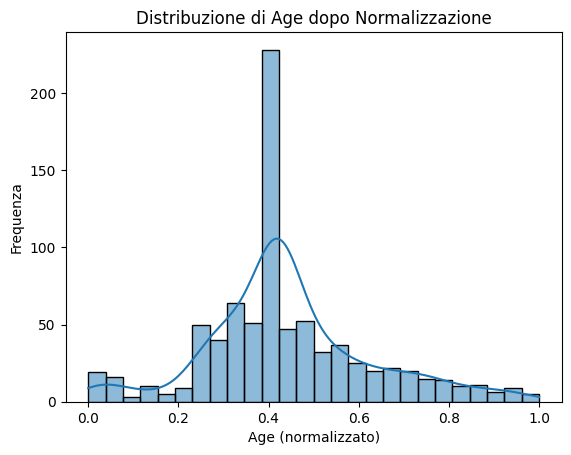

In [35]:
#perche family size contiene 524 record con 0 persone?
# Perché la colonna "family_size" è stata creata sommando le colonne "parch" (parenti a bordo) e "sibsp" (fratelli/sorelle a bordo).
# Se ci sono 524 record con "family_size" pari a 0, significa che in quei record specifici non c'erano né parenti né fratelli/sorelle a bordo.
# In altre parole, queste persone erano da sole durante il viaggio, senza familiari a bordo.

# Normalizzazione (Min-Max Scaling) su df_zscore
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
if df_zscore.empty:
    print("Il DataFrame è vuoto dopo la rimozione degli outlier. Non è possibile applicare la normalizzazione.")
else:
    df_zscore[['age', 'fare', 'parch', 'sibsp']] = scaler.fit_transform(df_zscore[['age', 'fare', 'parch', 'sibsp']])
    print(df_zscore[['age', 'fare', 'parch', 'sibsp']].describe())
    
sns.histplot(df_zscore['age'], kde=True)
plt.title('Distribuzione di Age dopo Normalizzazione')
plt.xlabel('Age (normalizzato)')
plt.ylabel('Frequenza')
plt.show()

## `applicare logistic regression`

Accuracy: 0.83


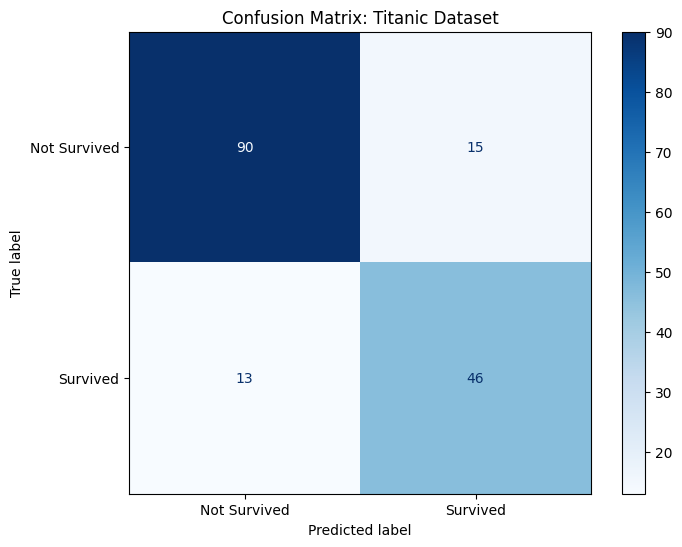

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Dataset setup
X = df_zscore.drop(columns=['survived']).values
y = df_zscore['survived'].values

# 2. Split (using your random_state 41)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

# 3. Model initialization and training
# max_iter increased to ensure convergence on this dataset
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# 4. Predictions
predictions = model.predict(X_test)

# 5. Accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')

# 6. CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Titanic Dataset')
plt.show()

## applico il modello del random forest al dataset del Titanic

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. Dataset setup - albero decisionale sul df di titanic che stavo usando prima
# con target "survived" e tutte le altre colonne come feature
X = df_zscore.drop(columns=['survived']).values
y = df_zscore['survived'].values

# 2. Split Train/Test (using your random_state 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model initialization and training - addestramento del modello XGBoost
# max_iter increased to ensure convergence on this dataset
xgb_model = XGBClassifier(n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    gamma=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42)
xgb_model.fit(X_train, y_train)

# 4. Predictions 
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Survived', 'Survived']))

'''# 6. CONFUSION MATRIX
cm = confusion_matrix(y_test, predictions)

# Visualization
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])
disp.plot(cmap='Blues', ax=ax)

plt.title('Confusion Matrix: Titanic Dataset')
plt.show()'''

              precision    recall  f1-score   support

Not Survived       0.85      0.90      0.87       104
    Survived       0.81      0.72      0.76        60

    accuracy                           0.84       164
   macro avg       0.83      0.81      0.82       164
weighted avg       0.83      0.84      0.83       164



c:\Users\mcvis\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:11:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


"# 6. CONFUSION MATRIX\ncm = confusion_matrix(y_test, predictions)\n\n# Visualization\nfig, ax = plt.subplots(figsize=(8, 6))\ndisp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Survived', 'Survived'])\ndisp.plot(cmap='Blues', ax=ax)\n\nplt.title('Confusion Matrix: Titanic Dataset')\nplt.show()"

## Creo nuove feature ingegnerizzate per aumentare la mia accuracy

- Age group?